In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier as knc
df=pd.read_csv(r"C:\Users\chait\Downloads\archive (1)\Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
df['Family']=df['Parch']+df['SibSp']+1

In [4]:
df['Age']=df['Age'].fillna(df['Age'].median())
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  Family       891 non-null    int64  
dtypes: float64(2), int64(6), str(5)
memory usage: 90.6 KB


In [18]:
df_new=df.drop(columns=['Cabin','PassengerId','Name','Ticket','Embarked','SibSp','Parch'])
df_new['Sex']=df_new['Sex'].map({'male':1,'female':0})
x=df_new.drop(columns=['Survived','Sex'])
y=df_new['Survived']
print(y.shape)
print(type(y))
x

(891,)
<class 'pandas.Series'>


,Pclass,Age,Fare,Family
0,3,22.0,7.2500,2
1,1,38.0,71.2833,2
2,3,26.0,7.9250,1
3,1,35.0,53.1000,2
4,3,35.0,8.0500,1
...,...,...,...,...
886,2,27.0,13.0000,1
887,1,19.0,30.0000,1
888,3,28.0,23.4500,4
889,1,26.0,30.0000,1


In [7]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_new=pd.DataFrame(sc.fit_transform(x),columns=x.columns,index=x.index)
x_new['Sex']=df_new['Sex']
x_new

,Pclass,Age,Fare,Family,Sex
0,0.827377,-0.565736,-0.502445,0.059160,1
1,-1.566107,0.663861,0.786845,0.059160,0
2,0.827377,-0.258337,-0.488854,-0.560975,0
3,-1.566107,0.433312,0.420730,0.059160,0
4,0.827377,0.433312,-0.486337,-0.560975,1
...,...,...,...,...,...
886,-0.369365,-0.181487,-0.386671,-0.560975,1
887,-1.566107,-0.796286,-0.044381,-0.560975,0
888,0.827377,-0.104637,-0.176263,1.299429,0
889,-1.566107,-0.258337,-0.044381,-0.560975,1


In [16]:
x_train,x_test,y_train,y_test=train_test_split(x_new,y,test_size=0.3)
print(type(y_test))
x_test

<class 'pandas.Series'>


,Pclass,Age,Fare,Family,Sex
333,0.827377,-1.026836,-0.285997,0.679295,1
353,0.827377,-0.335187,-0.290024,0.059160,1
351,-1.566107,-0.104637,0.056292,-0.560975,1
693,0.827377,-0.335187,-0.502949,-0.560975,1
742,-1.566107,-0.642586,4.634417,1.919564,0
...,...,...,...,...,...
562,-0.369365,-0.104637,-0.376603,-0.560975,1
330,0.827377,-0.104637,-0.180290,0.679295,0
781,-1.566107,-0.949986,0.499256,0.059160,0
430,-1.566107,-0.104637,-0.113846,-0.560975,1


In [9]:
x_train.info()
n=int((x_train.shape[0])*0.1)
n

<class 'pandas.DataFrame'>
Index: 623 entries, 834 to 603
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  623 non-null    float64
 1   Age     623 non-null    float64
 2   Fare    623 non-null    float64
 3   Family  623 non-null    float64
 4   Sex     623 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 29.2 KB


62

In [10]:
m=0
a=0
for i in range(1,n+1):    
    model=knc(n_neighbors=i)
    model.fit(x_train,y_train)
    x=model.score(x_test,y_test)
    if (m < x):
        m=x
        a=i
print(a)
model=knc(n_neighbors=a)
model.fit(x_train,y_train)


4


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [11]:
y_pred=model.predict(x_test)
print(model.score(x_test,y_test))
y_pred=pd.Series(y_pred)
y_pred

0.832089552238806


0      1
1      0
2      0
3      0
4      1
      ..
263    0
264    1
265    0
266    1
267    1
Length: 268, dtype: int64

In [12]:
import seaborn as sns
df_plot1=x_test
df_plot1['Survival']=y_test.map({0:'No',1:'Yes'})
df_plot1

,Pclass,Age,Fare,Family,Sex,Survival
708,-1.566107,-0.565736,2.402990,-0.560975,0,Yes
75,0.827377,-0.335187,-0.494391,-0.560975,1,No
470,0.827377,-0.104637,-0.502445,-0.560975,1,No
335,0.827377,-0.104637,-0.489442,-0.560975,1,No
546,-0.369365,-0.796286,-0.124920,0.059160,0,Yes
...,...,...,...,...,...,...
488,0.827377,0.049062,-0.486337,-0.560975,1,No
417,-0.369365,-0.873136,-0.386671,0.679295,0,Yes
180,0.827377,-0.104637,0.751946,5.640372,0,No
576,-0.369365,0.356462,-0.386671,-0.560975,0,Yes


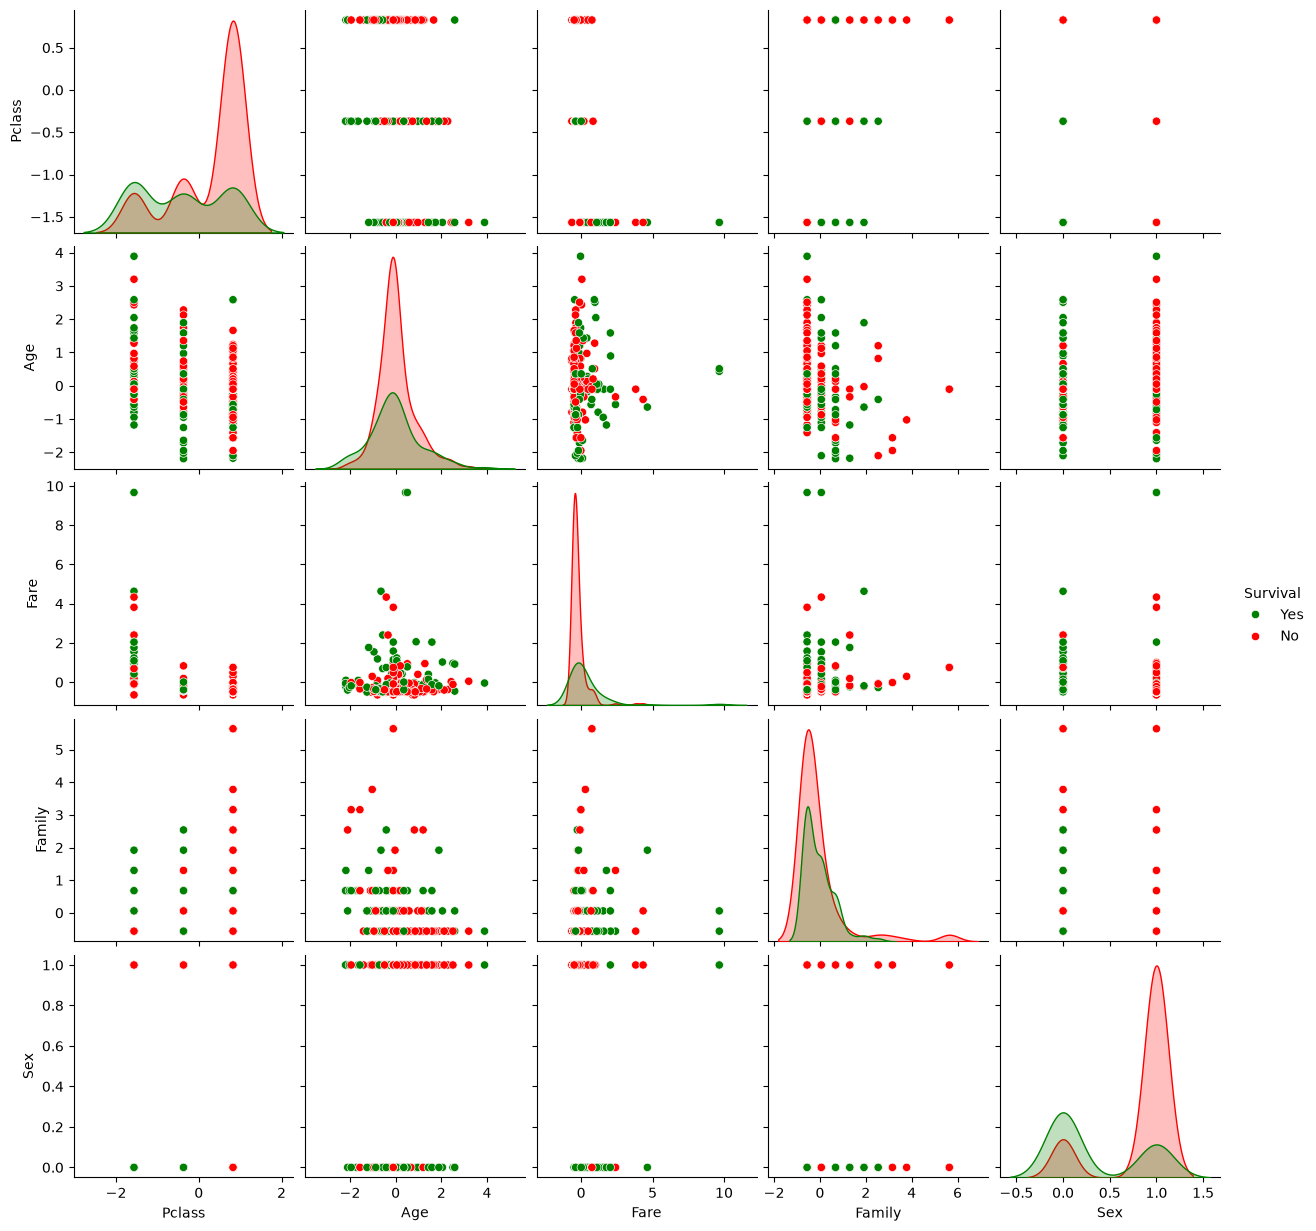

In [13]:
sns.pairplot(df_plot1,hue='Survival',palette={'Yes':'g','No':'r'})

In [14]:
df_plot2=x_test
df_plot2['Survival']=list(y_pred.map({0:'No',1:'Yes'}))
df_plot2

,Pclass,Age,Fare,Family,Sex,Survival
708,-1.566107,-0.565736,2.402990,-0.560975,0,Yes
75,0.827377,-0.335187,-0.494391,-0.560975,1,No
470,0.827377,-0.104637,-0.502445,-0.560975,1,No
335,0.827377,-0.104637,-0.489442,-0.560975,1,No
546,-0.369365,-0.796286,-0.124920,0.059160,0,Yes
...,...,...,...,...,...,...
488,0.827377,0.049062,-0.486337,-0.560975,1,No
417,-0.369365,-0.873136,-0.386671,0.679295,0,Yes
180,0.827377,-0.104637,0.751946,5.640372,0,No
576,-0.369365,0.356462,-0.386671,-0.560975,0,Yes


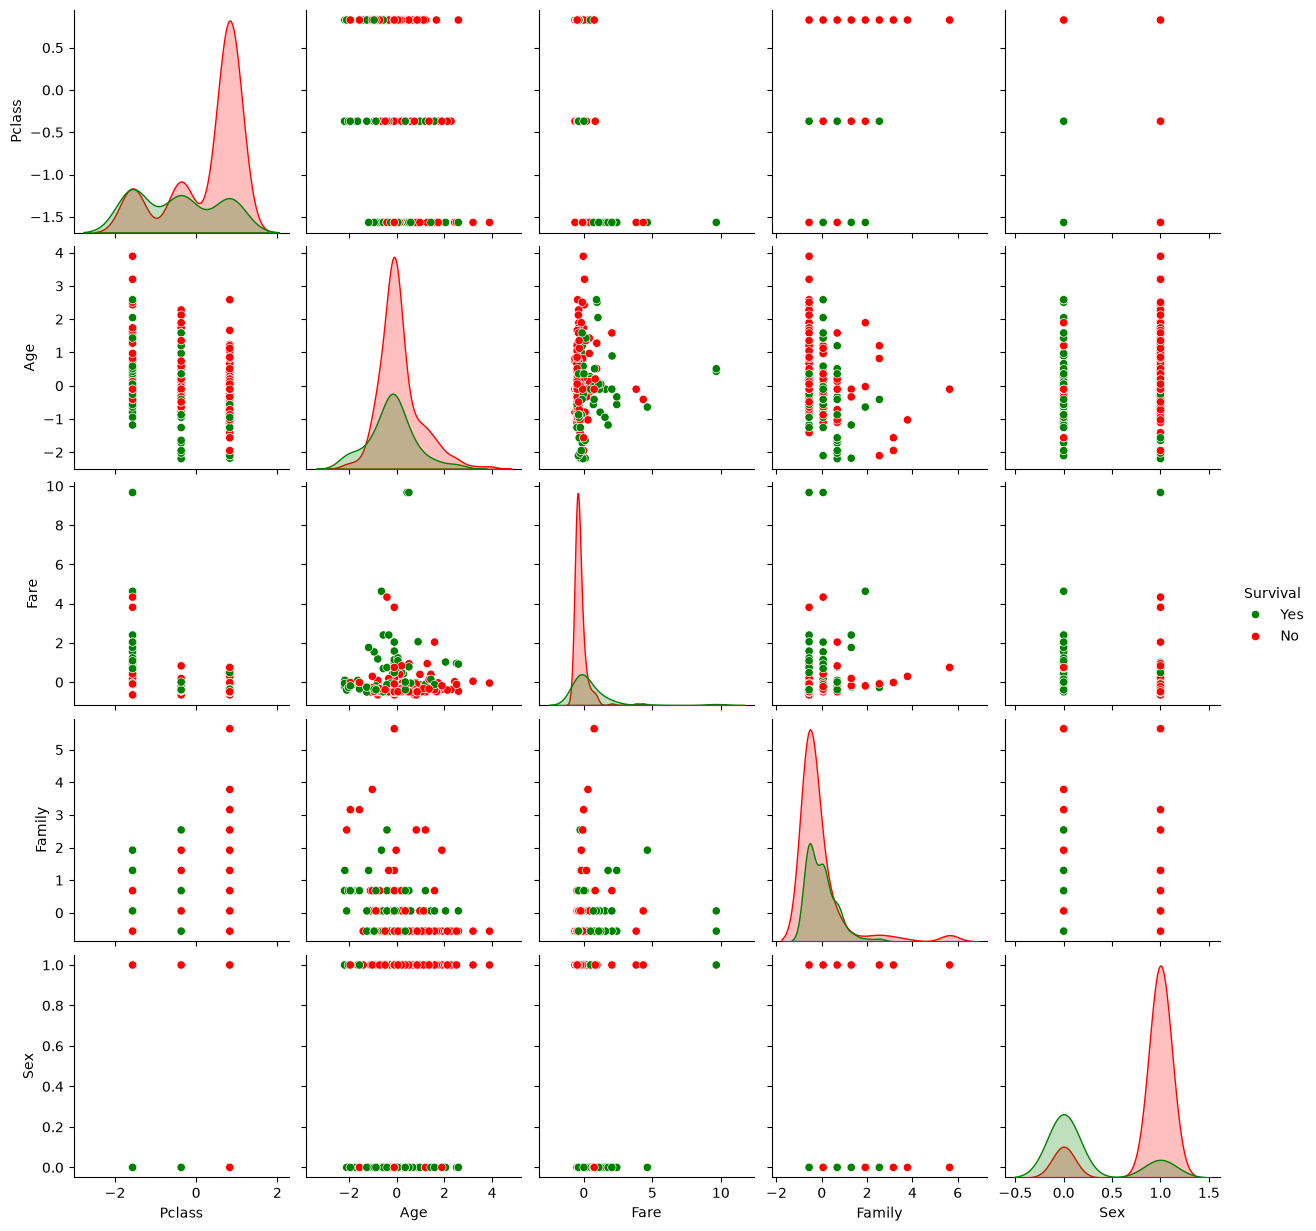

In [15]:
sns.pairplot(df_plot2,hue='Survival',palette={'Yes':'g','No':'r'})